In [1]:
import math
import jax
print(jax.devices())

[CudaDevice(id=0)]


In [2]:
import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import pandas as pd
import seaborn as sns
import tqdm
from networks import InvariantValueNet, ValueNet
random_key = jax.random.PRNGKey(42)


In [3]:
batch_size = 32
width = 32
sym_inv_reg_pairs = [(0.1,0.0), (1.0, 0.1), (1.0, 0.0)] #, (0.2, 0.0), (0.0, 0.1),(0.1, 0.1)]
value_net_equiv = InvariantValueNet(
    key=jax.random.PRNGKey(42),
    in_size=6 * 7 * 2,
    head_depth=2,
    head_width=width,
    body_depth=2,
    body_width=width,
    body_n_blocks=2,
    embed_dim=width,
    activation=jax.nn.gelu,
    n_actions=7,
    avg_symmetries=False,
    simple=False,
)


value_net_nosym = ValueNet(
    key=jax.random.PRNGKey(42),
    in_size=6 * 7 * 2,
    head_depth=2,
    head_width=width,
    body_depth=2,
    body_width=width,
    body_n_blocks=2,
    embed_dim=width,
    activation=jax.nn.gelu,
    n_actions=7,
    avg_symmetries=False,
    simple=False,
)

value_net_sym = ValueNet(
    key=jax.random.PRNGKey(42),
    in_size=6 * 7 * 2,
    head_depth=2,
    head_width=width,
    body_depth=2,
    body_width=width,
    body_n_blocks=2,
    embed_dim=width,
    activation=jax.nn.gelu,
    n_actions=7,
    avg_symmetries=True,
    simple=False,
)

value_net_nosym_regularized_models = []
for (alpha, interm_alpha) in sym_inv_reg_pairs:
    value_net_nosym_regularized_models.append(
        ValueNet(
            key=jax.random.PRNGKey(42),
            in_size=6 * 7 * 2,
            head_depth=2,
            head_width=width,
            body_depth=2,
            body_width=width,
            body_n_blocks=2,
            embed_dim=width,
            activation=jax.nn.gelu,
            n_actions=7,
            avg_symmetries=False,
            simple=False,
        )
    )

In [ ]:

opt = optax.adam(1e-3)
params_nosym = eqx.filter(value_net_nosym, eqx.is_inexact_array)
params_sym = eqx.filter(value_net_sym, eqx.is_inexact_array)
params_equiv = eqx.filter(value_net_equiv, eqx.is_inexact_array)
params_equiv_regularized_list = [eqx.filter(value_net_nosym_regularized_models[i], eqx.is_inexact_array) for i in range(len(sym_inv_reg_pairs))]
opt_state_nosym = opt.init(params_nosym)
opt_state_sym = opt.init(params_sym)
opt_state_equiv = opt.init(params_equiv)
opt_state_equiv_regularized_list = [opt.init(params_equiv_regularized_list[i]) for i in range(len(sym_inv_reg_pairs))]

_train_boards = np.load("train_boards.npy")
_train_values = np.load("train_values.npy")
_test_boards = np.load("test_boards.npy")
_test_values = np.load("test_values.npy")

key = jax.random.PRNGKey(0)
n_train = _train_boards.shape[0]
n_sample = int(n_train * 0.1)
indices = jax.random.choice(key, n_train, shape=(n_sample,), replace=False)
train_boards = jnp.stack([_train_boards[indices] == 1, _train_boards[indices] == 2], axis=-1).astype(jnp.float32)
train_values = jnp.asarray(_train_values[indices], dtype=jnp.float32)
test_boards = jnp.stack([_test_boards == 1, _test_boards == 2], axis=-1).astype(jnp.float32)
test_values = jnp.asarray(_test_values, dtype=jnp.float32)

@eqx.filter_jit
def get_batches(data, random_key, batch_size, drop_last):
    if not drop_last:
        raise NotImplementedError

    n_samples = jax.tree.leaves(data)[0].shape[0]
    n_batches = math.floor(n_samples / batch_size)

    idx = jax.random.permutation(random_key, jnp.arange(n_samples))[
        : n_batches * batch_size
    ]
    return jax.tree.map(
        lambda x: x[idx].reshape(n_batches, batch_size, *x.shape[1:]), data
    )

@eqx.filter_jit
def do_epoch(random_key, value_net, opt_state, obs, values, opt, batch_size, alpha=0.0, interm_alpha=0.0):
    params, static = eqx.partition(value_net, eqx.is_inexact_array)

    data = get_batches((obs, values), random_key, batch_size, drop_last=True)

    def body_fn(carry, x):
        params, opt_state = carry
        obs, values = x
        value_net = eqx.combine(params, static)

        (_, metrics), grads = eqx.filter_value_and_grad(loss_fn, has_aux=True)(
            value_net, obs, values, alpha, interm_alpha
        )
        updates, opt_state = opt.update(grads, opt_state)
        value_net = eqx.apply_updates(value_net, updates)
        params = eqx.filter(value_net, eqx.is_inexact_array)
        return (params, opt_state), (metrics)

    (params, opt_state), metrics = jax.lax.scan(body_fn, (params, opt_state), data)
    value_net = eqx.combine(params, static)
    return value_net, opt_state, metrics


@eqx.filter_jit
def loss_fn(value_net, obs, values, alpha=0.0, interm_alpha=0.0):
    preds, interms, blocks_interms, first, last = jax.vmap(value_net.forward)(obs)
    
    # interms is a list of [N, 32]
    # blocks_interms is a list of lists of [N, 32]
    # first a tensor [N, 32]
    # last a tensor [N, 32]
    
    # for i in range(len(interms)):
    #     print(f"interms {i} {interms[i].shape}")
    
    # for i in range(len(blocks_interms)):
    #     for j in range(len(blocks_interms[i])):
    #         print(f"blocks_interms {i} {j} {blocks_interms[i][j].shape}")
    
    # print(f"first {first.shape}")
    # print(f"last {last.shape}")
        
    loss_main = jnp.mean((preds - values) ** 2)
    
    sym_obs = jnp.flip(obs, axis=2) # obs shape is [N, 6, 7, 2]
    
    sym_preds, sym_interms, sym_blocks_interms, sym_first, sym_last = jax.vmap(value_net.forward)(sym_obs)
    inv_loss_final = jnp.mean((preds - sym_preds) ** 2)
    
    # interms loss components store
    interms_loss_components = {}
    # sum all interms components
    inv_loss_interms = 0.0
    for i in range(len(interms)):
        interms_loss_components[f"DenseResNetBlock{i}"] = jnp.mean((interms[i] - sym_interms[i]) ** 2)
        inv_loss_interms += jnp.mean((interms[i] - sym_interms[i]) ** 2)
    for i in range(len(blocks_interms)):
        for j in range(len(blocks_interms[i])):
            interms_loss_components[f"linear_module{i}_{j}"] = jnp.mean((blocks_interms[i][j] - sym_blocks_interms[i][j]) ** 2)
            inv_loss_interms += jnp.mean((blocks_interms[i][j] - sym_blocks_interms[i][j]) ** 2)
    interms_loss_components["first"] = jnp.mean((first - sym_first) ** 2)
    inv_loss_interms += jnp.mean((first - sym_first) ** 2)
    interms_loss_components["last"] = jnp.mean((last - sym_last) ** 2)
    inv_loss_interms += jnp.mean((last - sym_last) ** 2)
    
    # TODO weight equivariance loss, 
    # enforce Wx = Q W Px with P the symmetry and Q 
    # the permutation, here Q permutation like arange(dim)[::-1] 

    loss = loss_main + alpha * inv_loss_final + interm_alpha * inv_loss_interms
        
    return loss, {"value_loss":loss, "main_loss":loss_main, "inv_loss_final":inv_loss_final, "inv_loss_interms":inv_loss_interms, **interms_loss_components}
rows = []
n_epochs = 50
k = 0


def append_metrics_to_rows(rows, eval_lossdict, k, model_name="noname"):
    for key, value in eval_lossdict.items():
        row = {"value": float(value), "step": k, "metric": f"{model_name}_{key}"}
        rows.append(row)
    return rows

eval_loss_nosym, eval_lossdict_nosym = loss_fn(value_net_nosym, test_boards, test_values)
rows = append_metrics_to_rows(rows, eval_lossdict_nosym, k, "eval_nosym")

eval_loss_sym, eval_lossdict_sym = loss_fn(value_net_sym, test_boards, test_values)
rows = append_metrics_to_rows(rows, eval_lossdict_sym, k, "eval_sym")

value_net_nosym_evalsym = eqx.combine(
    eqx.filter(value_net_nosym, eqx.is_inexact_array),
    eqx.filter(value_net_sym, lambda x: not eqx.is_inexact_array(x)),
)
eval_loss_nosym_evalsym, eval_lossdict_nosym_evalsym = loss_fn(value_net_nosym_evalsym, test_boards, test_values)
rows = append_metrics_to_rows(rows, eval_lossdict_nosym_evalsym, k, "eval_nosym_inference_sym")

eval_loss_equiv, eval_lossdict_equiv = loss_fn(value_net_equiv, test_boards, test_values)
rows = append_metrics_to_rows(rows, eval_lossdict_equiv, k, "eval_equiv")


# row = {"value": float(eval_lossdict_nosym["main_loss"]), "step": k, "metric": "eval_nosym"}
# rows.append(row)
# row = {"value": float(eval_lossdict_sym["main_loss"]), "step": k, "metric": "eval_sym"}
# rows.append(row)
# row = {"value": float(eval_lossdict_nosym_evalsym["main_loss"]), "step": k, "metric": "eval_nosym_inference_sym"}
# rows.append(row)
# row = {"value": float(eval_lossdict_equiv["main_loss"]), "step": k, "metric": "eval_equiv"}
# rows.append(row)

for i, (alpha, interm_alpha) in enumerate(sym_inv_reg_pairs):
    eval_loss_nosym_regularized, eval_lossdict_nosym_regularized = loss_fn(value_net_nosym_regularized_models[i], test_boards, test_values, alpha=alpha, interm_alpha=interm_alpha)
    rows = append_metrics_to_rows(rows, eval_lossdict_nosym_regularized, k, f"eval_nosym_regularized_{alpha}_{interm_alpha}")
    # row = {"value": float(eval_lossdict_nosym_regularized["main_loss"]), "step": k, "metric": f"eval_nosym_regularized_{alpha}_{interm_alpha}"}
    # rows.append(row)




In [9]:
print(pd.DataFrame(rows))
metric_keys = eval_lossdict_nosym_regularized.keys()
print(metric_keys)

       value  step                                           metric
0   0.187870     0                     eval_nosym_DenseResNetBlock0
1   0.282540     0                     eval_nosym_DenseResNetBlock1
2   0.011821     0                                 eval_nosym_first
3   0.000229     0                        eval_nosym_inv_loss_final
4   1.092004     0                      eval_nosym_inv_loss_interms
..       ...   ...                                              ...
79  0.175882     0  eval_nosym_regularized_1.0_0.0_linear_module0_1
80  0.122237     0  eval_nosym_regularized_1.0_0.0_linear_module1_0
81  0.073232     0  eval_nosym_regularized_1.0_0.0_linear_module1_1
82  0.958149     0         eval_nosym_regularized_1.0_0.0_main_loss
83  0.958378     0        eval_nosym_regularized_1.0_0.0_value_loss

[84 rows x 3 columns]
dict_keys(['DenseResNetBlock0', 'DenseResNetBlock1', 'first', 'inv_loss_final', 'inv_loss_interms', 'last', 'linear_module0_0', 'linear_module0_1', 'linear_modul

In [10]:
for epoch in tqdm.trange(n_epochs):
    random_key, subkey = jax.random.split(random_key)
    value_net_nosym, opt_state_nosym, metrics_nosym = do_epoch(
        subkey,
        value_net_nosym,
        opt_state_nosym,
        train_boards,
        train_values,
        opt,
        batch_size,
    )

    value_net_sym, opt_state_sym, metrics_sym = do_epoch(
        subkey,
        value_net_sym,
        opt_state_sym,
        train_boards,
        train_values,
        opt,
        batch_size,
    )
    value_net_equiv, opt_state_equiv, metrics_equiv = do_epoch(
        subkey,
        value_net_equiv,
        opt_state_equiv,
        train_boards,
        train_values,
        opt,
        batch_size,
    )
    
    for i in range(len(sym_inv_reg_pairs)):
        value_net_nosym_regularized_models[i], opt_state_equiv_regularized_list[i], metrics_nosym_regularized = do_epoch(
            subkey,
            value_net_nosym_regularized_models[i],
            opt_state_equiv_regularized_list[i],
            train_boards,
            train_values,
            opt,
            batch_size,
            sym_inv_reg_pairs[i][0],
            sym_inv_reg_pairs[i][1],
        )
        
        
    n_updates = len(metrics_sym["value_loss"])

    # add_rows = [
    #     {"value": float(m), "step": k + i, "metric": "train_sym"}
    #     for (i, m) in enumerate(metrics_sym["value_loss"])
    # ]
    # rows += add_rows

    # add_rows = [
    #     {"value": float(m), "step": k + i, "metric": "train_nosym"}
    #     for (i, m) in enumerate(metrics_nosym["value_loss"])
    # ]
    # rows += add_rows

    # add_rows = [
    #     {"value": float(m), "step": k + i, "metric": "train_equiv"}
    #     for (i, m) in enumerate(metrics_equiv["value_loss"])
    # ]
    # rows += add_rows

    k += n_updates

    eval_loss_nosym, eval_lossdict_nosym = loss_fn(value_net_nosym, test_boards, test_values)
    rows = append_metrics_to_rows(rows, eval_lossdict_nosym, k, "eval_nosym")
    eval_loss_sym, eval_lossdict_sym = loss_fn(value_net_sym, test_boards, test_values)
    rows = append_metrics_to_rows(rows, eval_lossdict_sym, k, "eval_sym")
    eval_loss_equiv, eval_lossdict_equiv = loss_fn(value_net_equiv, test_boards, test_values)
    rows = append_metrics_to_rows(rows, eval_lossdict_equiv, k, "eval_equiv")
    value_net_nosym_evalsym = eqx.combine(
        eqx.filter(value_net_nosym, eqx.is_inexact_array),
        eqx.filter(value_net_sym, lambda x: not eqx.is_inexact_array(x)),
    )
    eval_loss_nosym_evalsym, eval_lossdict_nosym_evalsym = loss_fn(
        value_net_nosym_evalsym, test_boards, test_values
    )
    rows = append_metrics_to_rows(rows, eval_lossdict_nosym_evalsym, k, "eval_nosym_inference_sym")
    for i in range(len(sym_inv_reg_pairs)):
        loss, lossdict = loss_fn(value_net_nosym_regularized_models[i], test_boards, test_values, alpha=sym_inv_reg_pairs[i][0], interm_alpha=sym_inv_reg_pairs[i][1])
        rows = append_metrics_to_rows(rows, lossdict, k, f"eval_nosym_regularized_{sym_inv_reg_pairs[i][0]}_{sym_inv_reg_pairs[i][1]}")
    
    # row = {"value": float(eval_lossdict_nosym["main_loss"]), "step": k, "metric": "eval_nosym"}
    # rows.append(row)
    # row = {"value": float(eval_lossdict_sym["main_loss"]), "step": k, "metric": "eval_sym"}
    # rows.append(row)
    # row = {"value": float(eval_lossdict_nosym_evalsym["main_loss"]), "step": k, "metric": "eval_nosym_inference_sym"}
    # rows.append(row)
    # row = {"value": float(eval_lossdict_equiv["main_loss"]), "step": k, "metric": "eval_equiv"}
    # rows.append(row)
    # for i in range(len(sym_inv_reg_pairs)):
    #     row = {"value": float(eval_lossdict_nosym_regularized_list[i]["main_loss"]), "step": k, "metric": f"eval_nosym_regularized_{sym_inv_reg_pairs[i][0]}_{sym_inv_reg_pairs[i][1]}"}
    #     rows.append(row)
    #     # store invariance finale loos
    #     row = {"value": float(eval_lossdict_nosym_regularized_list[i]["inv_loss_final"]), "step": k, "metric": f"inv_loss_final_nosym_regularized_{sym_inv_reg_pairs[i][0]}_{sym_inv_reg_pairs[i][1]}"}
    #     rows.append(row)
    #     # store invariance interms loss
    #     row = {"value": float(eval_lossdict_nosym_regularized_list[i]["inv_loss_interms"]), "step": k, "metric": f"inv_loss_interms_nosym_regularized_{sym_inv_reg_pairs[i][0]}_{sym_inv_reg_pairs[i][1]}"}
    #     rows.append(row)
    

  0%|          | 0/50 [00:00<?, ?it/s]2026-04-21 10:57:52.522142: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-04-21 10:57:52.522171: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-04-21 10:57:52.522180: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-04-21 10:57:52.522

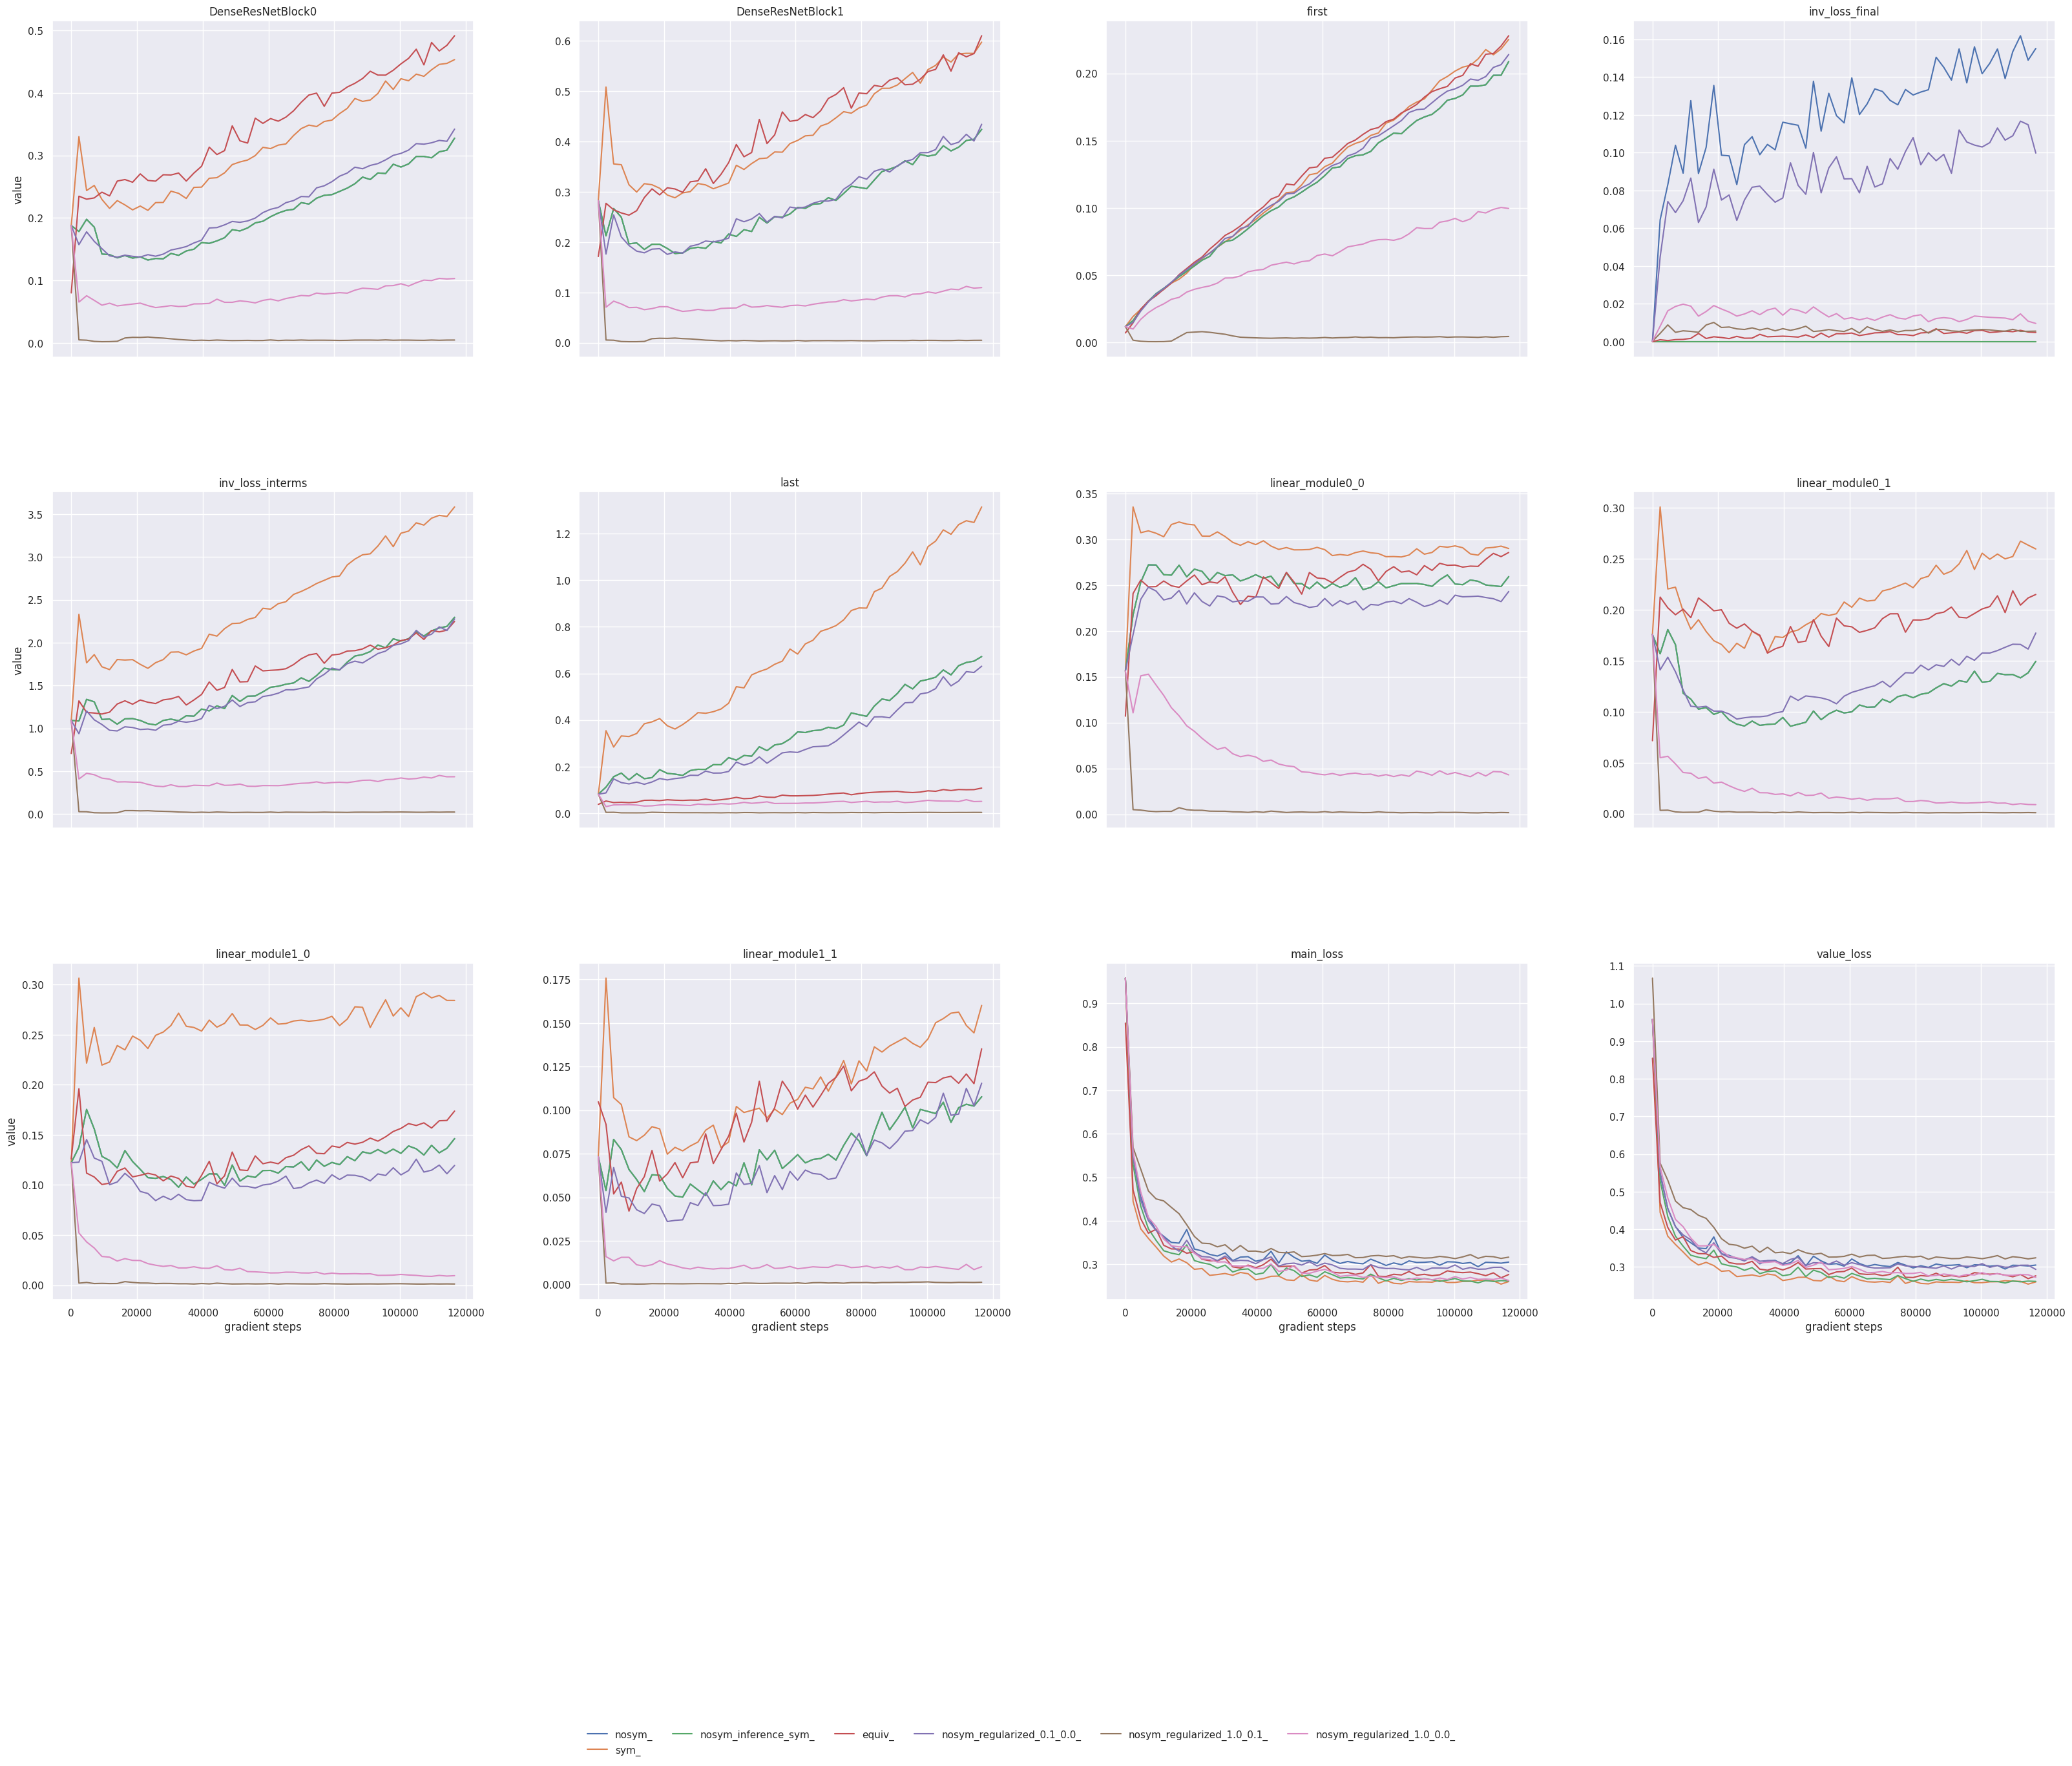

In [23]:
df = pd.DataFrame(rows)

sns.set_theme()
plot_df_all = df[df.metric.str.contains("eval")].copy()
plot_df_all.loc[:, "metric"] = plot_df_all["metric"].str.replace(r"^eval_", "", regex=True)

nrows, ncols = 3, 4
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(10 * ncols, 10 * nrows),
    sharex=True,
    sharey=False,
)
axes = axes.ravel()

max_plots = nrows * ncols
metric_keys = list(metric_keys)
n_plots = min(len(metric_keys), max_plots)

legend_handles = None
legend_labels = None

for i in range(n_plots):
    metricname = metric_keys[i]
    ax = axes[i]

    plot_df = plot_df_all[plot_df_all.metric.str.endswith(metricname)]
    sns.lineplot(
        data=plot_df,
        x="step",
        y="value",
        hue="metric",
        ax=ax,
        legend=(i == 0),
    )

    ax.set_title(metricname)

    if i >= (nrows - 1) * ncols:
        ax.set_xlabel("gradient steps")
    else:
        ax.set_xlabel("")

    if i % ncols != 0:
        ax.set_ylabel("")

    if i == 0:
        legend_handles, legend_labels = ax.get_legend_handles_labels()
        if ax.get_legend() is not None:
            ax.get_legend().remove()
    else:
        if ax.get_legend() is not None:
            ax.get_legend().remove()

for j in range(n_plots, max_plots):
    fig.delaxes(axes[j])
    
legend_labels_short = []
legend_labels_suffix = legend_labels[0].split("_")[-1]
for lab in legend_labels:
    lab = lab.replace(legend_labels_suffix, "")
    legend_labels_short.append(lab)

if legend_handles and legend_labels:
    fig.legend(
        legend_handles,
        legend_labels_short,
        loc="lower center",
        ncol=min(len(legend_labels), 6),
        frameon=False,
        bbox_to_anchor=(0.5, -0.02),
    )

fig.subplots_adjust(bottom=0.22, wspace=0.25, hspace=0.4)